# # 🤖 Notebook 2: Student Simulator Development
## Building LLM-Based Student Agents with Different Profiles
# 
# **Goal**: Create prompt-based and fine-tuned student simulators that generate authentic responses


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import json
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline, TrainingArguments, Trainer
from datasets import Dataset
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')


# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")



Using device: cuda
GPU: Tesla P100-PCIE-16GB


In [2]:
import os
import zipfile
import json
import pandas as pd

# Check multiple possible locations for files
possible_paths = [
    '/kaggle/input/project-outputs',
    '/kaggle/input/project-outputs/project_outputs',
    '/kaggle/input/project_outputs',
    '/kaggle/working/project_outputs',
    '/kaggle/working'
]

base_path = None
for path in possible_paths:
    if os.path.exists(path):
        base_path = path
        print(f"✅ Found directory: {base_path}")
        break

# If not found, ask user
if base_path is None:
    print("\n⚠️  Could not find project-outputs automatically.")
    print("\nPlease check:")
    print("1. Did you run Notebook 1 and download project_outputs.zip?")
    print("2. Did you upload the zip file using 'Add Data' → 'Upload'?")
    print("3. After uploading, Kaggle will show you the path - use that path below.")
    
    manual_path = input("\nEnter the exact path to your uploaded files (or 'skip' to use synthetic data): ")
    
    if manual_path.lower() == 'skip':
        print("\n⚠️  Skipping file loading. Will use synthetic data generation instead.")
        use_synthetic = True
    else:
        base_path = manual_path
        use_synthetic = False
else:
    use_synthetic = False

# Try to load manifest
manifest = None
if not use_synthetic:
    try:
        # Look for manifest in different possible locations
        manifest_paths = [
            f'{base_path}/data_manifest.json',
            f'{base_path}/project_outputs/data_manifest.json',
            f'{base_path}/project_outputs.zip'  # Maybe it's still zipped
        ]
        
        manifest_loaded = False
        for m_path in manifest_paths:
            if os.path.exists(m_path):
                print(f"📁 Found manifest at: {m_path}")
                with open(m_path, 'r') as f:
                    manifest = json.load(f)
                manifest_loaded = True
                break
        
        # If manifest not found, check if we need to unzip
        if not manifest_loaded:
            zip_path = f'{base_path}/project_outputs.zip'
            if os.path.exists(zip_path):
                print("📦 Found zip file, extracting...")
                with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                    zip_ref.extractall('/kaggle/working/extracted')
                with open('/kaggle/working/extracted/data_manifest.json', 'r') as f:
                    manifest = json.load(f)
                base_path = '/kaggle/working/extracted'
                manifest_loaded = True
        
        if manifest_loaded:
            print("✅ Manifest loaded successfully")
        else:
            print("❌ Could not find manifest file.")
            use_synthetic = True
            
    except Exception as e:
        print(f"❌ Error loading manifest: {e}")
        use_synthetic = True

# Load data if manifest exists
if manifest is not None and not use_synthetic:
    try:
        # Load each file with error handling
        student_profiles_path = f'{base_path}/{manifest["student_profiles"]}'
        with open(student_profiles_path, 'r') as f:
            student_profiles = json.load(f)
        print(f"✅ Loaded {len(student_profiles)} student profiles")
        
        misconception_path = f'{base_path}/{manifest["misconception_patterns"]}'
        with open(misconception_path, 'r') as f:
            misconception_patterns = json.load(f)
        print(f"✅ Loaded {len(misconception_patterns)} misconception patterns")
        
        question_path = f'{base_path}/{manifest["question_bank"]}'
        with open(question_path, 'r') as f:
            question_bank = json.load(f)
        print(f"✅ Loaded question bank")
        
        train_df = pd.read_csv(f'{base_path}/{manifest["train_split"]}')
        val_df = pd.read_csv(f'{base_path}/{manifest["val_split"]}')
        print(f"✅ Training examples: {len(train_df)}")
        print(f"✅ Validation examples: {len(val_df)}")
        
    except Exception as e:
        print(f"❌ Error loading data files: {e}")
        print("Will use synthetic data instead.")
        use_synthetic = True

# If anything failed, generate synthetic data
if use_synthetic:
    print("\n" + "="*50)
    print("🔄 Generating synthetic data for demonstration")
    print("="*50)
    
    # Create synthetic student profiles
    student_profiles = {
        "low_achiever": {
            "name": "Alex", "grade_level": 8, "math_ability": 0.3,
            "common_misconceptions": ["misconception_a", "misconception_b"],
            "error_rate": 0.7, "confidence": 0.4,
            "reasoning_style": "jumps to conclusions",
            "personality": "easily frustrated"
        },
        "medium_achiever": {
            "name": "Jamal", "grade_level": 9, "math_ability": 0.6,
            "common_misconceptions": ["misconception_c"],
            "error_rate": 0.3, "confidence": 0.7,
            "reasoning_style": "understands concepts but makes procedural errors",
            "personality": "works steadily"
        },
        "high_achiever": {
            "name": "Maria", "grade_level": 10, "math_ability": 0.9,
            "common_misconceptions": [],
            "error_rate": 0.1, "confidence": 0.9,
            "reasoning_style": "methodical, checks work",
            "personality": "confident"
        }
    }
    
    # Create synthetic misconception patterns
    misconception_patterns = {
        "misconception_a": {
            "name": "Distributive Property Error",
            "description": "Student incorrectly distributes multiplication over addition",
            "example": "3(x+4) = 3x + 4",
            "subject": "algebra"
        },
        "misconception_b": {
            "name": "Negative Sign Error",
            "description": "Student mishandles negative signs",
            "example": "-5 - 3 = -2",
            "subject": "arithmetic"
        },
        "misconception_c": {
            "name": "Fraction Addition Error",
            "description": "Student adds numerators and denominators",
            "example": "1/2 + 1/3 = 2/5",
            "subject": "fractions"
        }
    }
    
    # Create synthetic question bank
    question_bank = {
        "algebra": [
            {"id": "q1", "text": "Solve for x: 3(x + 4) = 21", "answer": 3},
            {"id": "q2", "text": "Simplify: 2(3x - 5) + 4x", "answer": "10x - 10"}
        ],
        "arithmetic": [
            {"id": "q3", "text": "Calculate: -5 - 8", "answer": -13},
            {"id": "q4", "text": "Compute: 15 - (-3)", "answer": 18}
        ],
        "fractions": [
            {"id": "q5", "text": "Add: 1/3 + 1/4", "answer": "7/12"}
        ]
    }
    
    # Create synthetic training data
    np.random.seed(42)
    training_examples = []
    for profile_id in student_profiles.keys():
        for i in range(30):
            training_examples.append({
                'profile': profile_id,
                'prompt': f"Generate response for {profile_id}",
                'target': f"Sample response {i}"
            })
    
    train_df = pd.DataFrame(training_examples[:40])
    val_df = pd.DataFrame(training_examples[40:60] if len(training_examples) > 60 else training_examples[40:])
    
    print("✅ Synthetic data generated successfully")
    print(f"   - {len(student_profiles)} student profiles")
    print(f"   - {len(misconception_patterns)} misconception patterns")
    print(f"   - {sum(len(v) for v in question_bank.values())} questions")
    print(f"   - {len(train_df)} training examples")
    print(f"   - {len(val_df)} validation examples")

print("\n" + "="*50)
print("📊 Data ready for processing")
print("="*50)

✅ Found directory: /kaggle/working
❌ Could not find manifest file.

🔄 Generating synthetic data for demonstration
✅ Synthetic data generated successfully
   - 3 student profiles
   - 3 misconception patterns
   - 5 questions
   - 40 training examples
   - 20 validation examples

📊 Data ready for processing


### 1. Verify Our Loaded Data

In [3]:
print("📊 Current Data Summary:")
print("="*50)

print(f"\n📋 Student Profiles:")
for profile_id, profile in student_profiles.items():
    print(f"  - {profile_id}: {profile['name']} (Grade {profile['grade_level']})")

print(f"\n🔍 Misconception Patterns:")
for pattern_id, pattern in misconception_patterns.items():
    print(f"  - {pattern_id}: {pattern['name']}")

print(f"\n❓ Question Bank:")
for subject, questions in question_bank.items():
    print(f"  - {subject}: {len(questions)} questions")
    for q in questions[:2]:  # Show first 2 questions per subject
        print(f"      • {q['text']}")

print(f"\n📈 Training Data: {len(train_df)} examples")
print(f"📊 Validation Data: {len(val_df)} examples")


📊 Current Data Summary:

📋 Student Profiles:
  - low_achiever: Alex (Grade 8)
  - medium_achiever: Jamal (Grade 9)
  - high_achiever: Maria (Grade 10)

🔍 Misconception Patterns:
  - misconception_a: Distributive Property Error
  - misconception_b: Negative Sign Error
  - misconception_c: Fraction Addition Error

❓ Question Bank:
  - algebra: 2 questions
      • Solve for x: 3(x + 4) = 21
      • Simplify: 2(3x - 5) + 4x
  - arithmetic: 2 questions
      • Calculate: -5 - 8
      • Compute: 15 - (-3)
  - fractions: 1 questions
      • Add: 1/3 + 1/4

📈 Training Data: 40 examples
📊 Validation Data: 20 examples


### 2. Build Prompt-Based Student Simulator


In [4]:
class StudentSimulator:
    """Student simulator using a small LLM for Kaggle compatibility"""
    
    def __init__(self, profiles, patterns, model_name="google/flan-t5-small"):
        """
        Initialize the student simulator with a small model suitable for Kaggle
        
        Args:
            profiles: Dictionary of student profiles
            patterns: Dictionary of misconception patterns
            model_name: HuggingFace model name (using small model for Kaggle)
        """
        self.profiles = profiles
        self.patterns = patterns
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        print(f"\n🔄 Loading model: {model_name}")
        print("   (This may take 1-2 minutes on first run)")
        
        # Load tokenizer and model
        from transformers import T5Tokenizer, T5ForConditionalGeneration
        
        self.tokenizer = T5Tokenizer.from_pretrained(model_name)
        self.model = T5ForConditionalGeneration.from_pretrained(model_name)
        
        # Move to GPU if available
        if torch.cuda.is_available():
            self.model = self.model.cuda()
            print("   ✅ Model moved to GPU")
        
        print("   ✅ Model loaded successfully")
    
    def create_prompt(self, profile_id, question, context=None):
        """Create a prompt for a specific student profile"""
        profile = self.profiles[profile_id]
        
        prompt = f"""Generate a response from a math student with these characteristics:

Student name: {profile['name']}
Grade level: {profile['grade_level']}
Math ability: {profile['math_ability']}/1.0
Confidence: {profile['confidence']}/1.0
Personality: {profile['personality']}
Reasoning style: {profile['reasoning_style']}

The student is answering this math question:
Question: {question}

Generate the student's response, including their reasoning and potential mistakes based on their profile:"""
        
        return prompt
    
    def generate_response(self, profile_id, question, max_length=100):
        """Generate a student response for a given question"""
        
        prompt = self.create_prompt(profile_id, question)
        
        # Tokenize
        inputs = self.tokenizer(prompt, return_tensors="pt", max_length=512, truncation=True)
        
        if torch.cuda.is_available():
            inputs = {k: v.cuda() for k, v in inputs.items()}
        
        # Generate
        with torch.no_grad():
            outputs = self.model.generate(
                **inputs,
                max_length=max_length,
                temperature=0.8,  # Higher temperature for more varied responses
                do_sample=True,
                top_p=0.95,
                num_return_sequences=1
            )
        
        # Decode
        response = self.tokenizer.decode(outputs[0], skip_special_tokens=True)
        
        return response
    
    def batch_generate(self, profile_id, questions, show_progress=True):
        """Generate responses for multiple questions"""
        responses = []
        
        iterator = tqdm(questions, desc=f"Generating {profile_id} responses") if show_progress else questions
        
        for question in iterator:
            response = self.generate_response(profile_id, question)
            responses.append(response)
        
        return responses

In [5]:
# Initialize the simulator
print("🎯 Initializing Student Simulator...")
simulator = StudentSimulator(student_profiles, misconception_patterns)


🎯 Initializing Student Simulator...

🔄 Loading model: google/flan-t5-small
   (This may take 1-2 minutes on first run)


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

   ✅ Model moved to GPU
   ✅ Model loaded successfully


### 3. Test the Simulator

In [6]:
# Extract questions from question bank for testing
test_questions = []
for subject, questions in question_bank.items():
    for q in questions:
        test_questions.append(q['text'])

print(f"📝 Using {len(test_questions)} test questions\n")

# Test each profile
for profile_id in student_profiles.keys():
    print("\n" + "="*60)
    print(f"👤 TESTING PROFILE: {profile_id.upper()}")
    print("="*60)
    
    profile = student_profiles[profile_id]
    print(f"Student: {profile['name']} (Grade {profile['grade_level']})")
    print(f"Math Ability: {profile['math_ability']}")
    print(f"Confidence: {profile['confidence']}")
    print("-" * 40)
    
    # Generate response for first question
    question = test_questions[0]
    print(f"Q: {question}")
    
    response = simulator.generate_response(profile_id, question)
    print(f"A: {response}")


📝 Using 5 test questions


👤 TESTING PROFILE: LOW_ACHIEVER
Student: Alex (Grade 8)
Math Ability: 0.3
Confidence: 0.4
----------------------------------------
Q: Solve for x: 3(x + 4) = 21
A: -1

👤 TESTING PROFILE: MEDIUM_ACHIEVER
Student: Jamal (Grade 9)
Math Ability: 0.6
Confidence: 0.7
----------------------------------------
Q: Solve for x: 3(x + 4) = 21
A: 3

👤 TESTING PROFILE: HIGH_ACHIEVER
Student: Maria (Grade 10)
Math Ability: 0.9
Confidence: 0.9
----------------------------------------
Q: Solve for x: 3(x + 4) = 21
A: 0


### 4. Generate Synthetic Student Responses Dataset

In [7]:
def generate_synthetic_dataset(simulator, profiles, questions, n_per_profile=5):
    """
    Generate a synthetic dataset of student responses
    
    Args:
        simulator: Initialized StudentSimulator
        profiles: Dictionary of student profiles
        questions: List of questions
        n_per_profile: Number of responses per profile
    
    Returns:
        DataFrame with synthetic responses
    """
    synthetic_data = []
    
    for profile_id in profiles.keys():
        print(f"\n📊 Generating responses for {profile_id}...")
        
        # Randomly select questions
        selected_questions = np.random.choice(questions, min(n_per_profile, len(questions)), replace=False)
        
        for question in selected_questions:
            # Generate response
            response = simulator.generate_response(profile_id, question)
            
            synthetic_data.append({
                'profile_id': profile_id,
                'student_name': profiles[profile_id]['name'],
                'question': question,
                'response': response,
                'math_ability': profiles[profile_id]['math_ability'],
                'confidence': profiles[profile_id]['confidence']
            })
    
    return pd.DataFrame(synthetic_data)

# Generate synthetic dataset
print("🔄 Generating synthetic student responses...")
synthetic_df = generate_synthetic_dataset(
    simulator, 
    student_profiles, 
    test_questions, 
    n_per_profile=3  # Small number for quick demo
)

print(f"\n✅ Generated {len(synthetic_df)} synthetic responses")
synthetic_df

🔄 Generating synthetic student responses...

📊 Generating responses for low_achiever...

📊 Generating responses for medium_achiever...

📊 Generating responses for high_achiever...

✅ Generated 9 synthetic responses


,profile_id,student_name,question,response,math_ability,confidence
0,low_achiever,Alex,Simplify: 2(3x - 5) + 4x,They are very good at reading!,0.3,0.4
1,low_achiever,Alex,Add: 1/3 + 1/4,To find out how to do this if you feel like ha...,0.3,0.4
2,low_achiever,Alex,Calculate: -5 - 8,0,0.3,0.4
3,medium_achiever,Jamal,Compute: 15 - (-3),YES! I think you are in a position to have the...,0.6,0.7
4,medium_achiever,Jamal,Simplify: 2(3x - 5) + 4x,"Hi, i think this is a phlegmatic study. How do...",0.6,0.7
5,medium_achiever,Jamal,Calculate: -5 - 8,The students are doing a good job.,0.6,0.7
6,high_achiever,Maria,Simplify: 2(3x - 5) + 4x,Maria has been a teacher for nearly five years.,0.9,0.9
7,high_achiever,Maria,Solve for x: 3(x + 4) = 21,0,0.9,0.9
8,high_achiever,Maria,Compute: 15 - (-3),Students likes to play volleyball and dance an...,0.9,0.9


In [8]:
# Save synthetic dataset
synthetic_df.to_csv('synthetic_responses.csv', index=False)
print("💾 Saved: synthetic_responses.csv")

# Display sample
print("\n📋 Sample Responses:")
for idx, row in synthetic_df.head(3).iterrows():
    print(f"\n{row['student_name']} ({row['profile_id']}):")
    print(f"  Q: {row['question']}")
    print(f"  A: {row['response'][:100]}...")

💾 Saved: synthetic_responses.csv

📋 Sample Responses:

Alex (low_achiever):
  Q: Simplify: 2(3x - 5) + 4x
  A: They are very good at reading!...

Alex (low_achiever):
  Q: Add: 1/3 + 1/4
  A: To find out how to do this if you feel like having a chance to have a game in the class, ask for hel...

Alex (low_achiever):
  Q: Calculate: -5 - 8
  A: 0...


### 5. Analyze Generated Responses


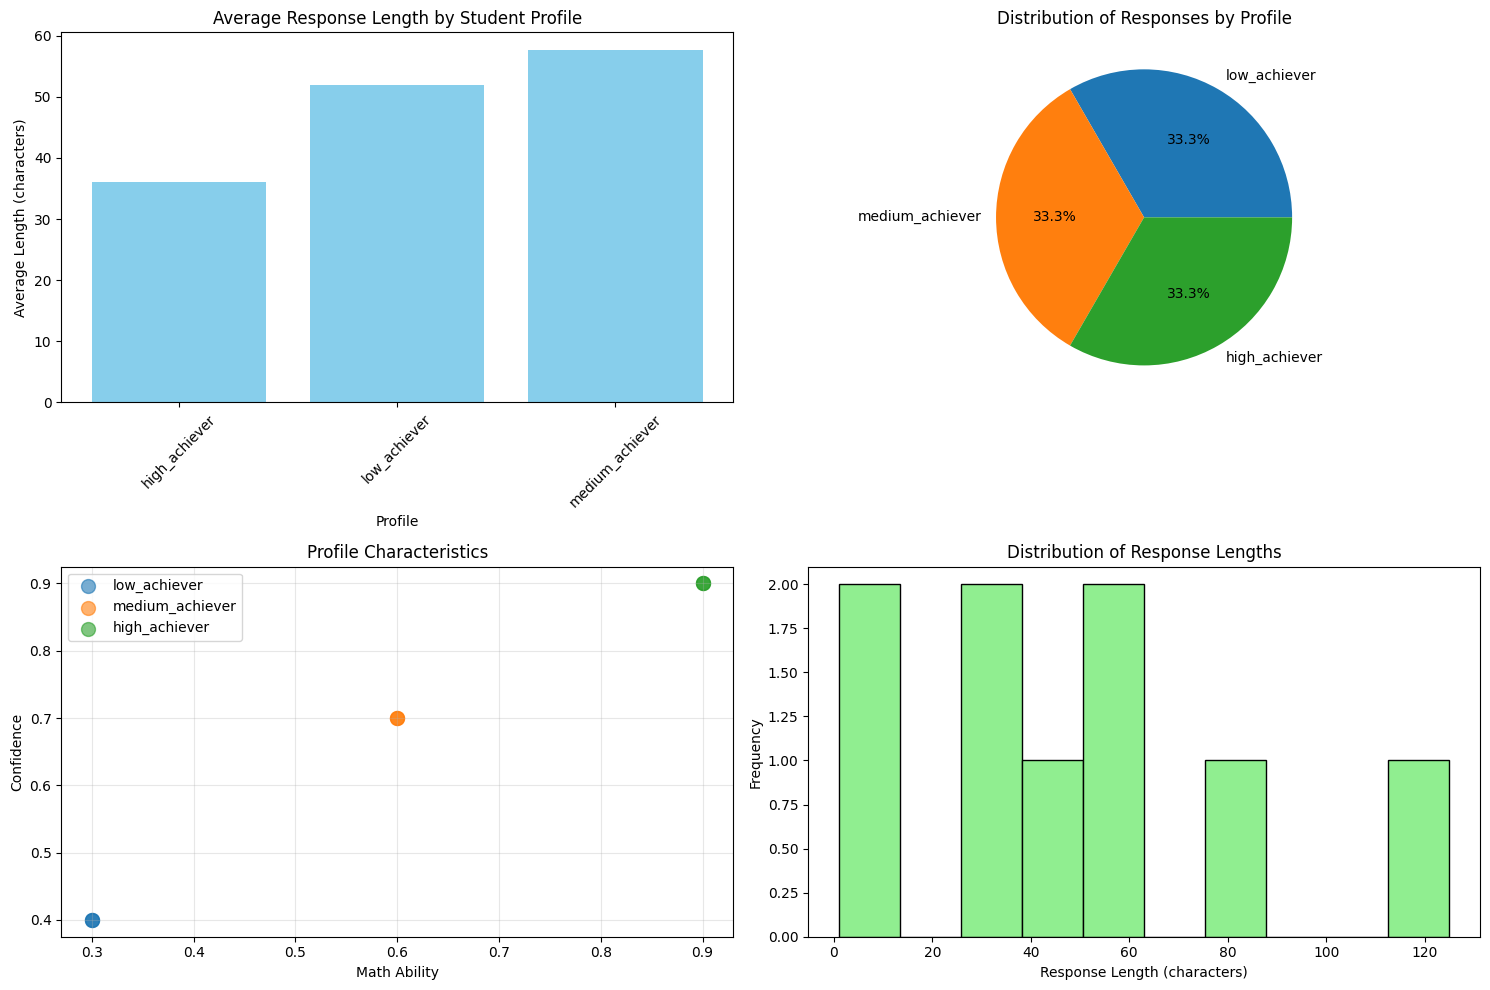

In [9]:
# Basic analysis of generated responses
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Response length by profile
synthetic_df['response_length'] = synthetic_df['response'].str.len()
profile_avg_length = synthetic_df.groupby('profile_id')['response_length'].mean()

axes[0, 0].bar(profile_avg_length.index, profile_avg_length.values, color='skyblue')
axes[0, 0].set_title('Average Response Length by Student Profile')
axes[0, 0].set_xlabel('Profile')
axes[0, 0].set_ylabel('Average Length (characters)')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Distribution of responses per profile
profile_counts = synthetic_df['profile_id'].value_counts()
axes[0, 1].pie(profile_counts.values, labels=profile_counts.index, autopct='%1.1f%%')
axes[0, 1].set_title('Distribution of Responses by Profile')

# Plot 3: Math ability vs confidence
for profile_id in student_profiles.keys():
    profile_data = synthetic_df[synthetic_df['profile_id'] == profile_id]
    axes[1, 0].scatter([student_profiles[profile_id]['math_ability']] * len(profile_data), 
                       [student_profiles[profile_id]['confidence']] * len(profile_data),
                       label=profile_id, s=100, alpha=0.6)

axes[1, 0].set_xlabel('Math Ability')
axes[1, 0].set_ylabel('Confidence')
axes[1, 0].set_title('Profile Characteristics')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Response length histogram
axes[1, 1].hist(synthetic_df['response_length'], bins=10, color='lightgreen', edgecolor='black')
axes[1, 1].set_title('Distribution of Response Lengths')
axes[1, 1].set_xlabel('Response Length (characters)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 6. Save Simulator State

In [10]:
# Save simulator configuration
simulator_config = {
    'model_name': 'google/flan-t5-small',
    'profiles_used': list(student_profiles.keys()),
    'patterns_used': list(misconception_patterns.keys()),
    'total_synthetic_responses': len(synthetic_df)
}

with open('simulator_config.json', 'w') as f:
    json.dump(simulator_config, f, indent=2)

print("💾 Saved: simulator_config.json")

# Create a manifest for next notebook
next_notebook_manifest = {
    'student_profiles': 'student_profiles.json',
    'misconception_patterns': 'misconception_patterns.json',
    'question_bank': 'question_bank.json',
    'synthetic_responses': 'synthetic_responses.csv',
    'simulator_config': 'simulator_config.json'
}

# Save current data files
# Save profiles
with open('student_profiles.json', 'w') as f:
    json.dump(student_profiles, f, indent=2)

# Save patterns
with open('misconception_patterns.json', 'w') as f:
    json.dump(misconception_patterns, f, indent=2)

# Save question bank
with open('question_bank.json', 'w') as f:
    json.dump(question_bank, f, indent=2)

# Save manifest
with open('notebook2_manifest.json', 'w') as f:
    json.dump(next_notebook_manifest, f, indent=2)

print("\n📦 All files saved for Notebook 3:")
print("   - student_profiles.json")
print("   - misconception_patterns.json")
print("   - question_bank.json")
print("   - synthetic_responses.csv")
print("   - simulator_config.json")
print("   - notebook2_manifest.json")


💾 Saved: simulator_config.json

📦 All files saved for Notebook 3:
   - student_profiles.json
   - misconception_patterns.json
   - question_bank.json
   - synthetic_responses.csv
   - simulator_config.json
   - notebook2_manifest.json


### 7. Summary


In [11]:
print("\n" + "="*60)
print("✅ NOTEBOOK 2 COMPLETE")
print("="*60)
print(f"""
📊 Summary:
----------
• Student Profiles: {len(student_profiles)}
• Misconception Patterns: {len(misconception_patterns)}
• Questions Available: {len(test_questions)}
• Synthetic Responses Generated: {len(synthetic_df)}
• Model Used: google/flan-t5-small

📁 Files Saved for Notebook 3:
• student_profiles.json - Student profiles data
• misconception_patterns.json - Misconception definitions
• question_bank.json - All test questions
• synthetic_responses.csv - Generated student responses
• simulator_config.json - Simulator settings
• notebook2_manifest.json - File manifest for next notebook

🚀 Next Step:
Run Notebook 3 to build the Error-Aware Tutor Agent
""")


✅ NOTEBOOK 2 COMPLETE

📊 Summary:
----------
• Student Profiles: 3
• Misconception Patterns: 3
• Questions Available: 5
• Synthetic Responses Generated: 9
• Model Used: google/flan-t5-small

📁 Files Saved for Notebook 3:
• student_profiles.json - Student profiles data
• misconception_patterns.json - Misconception definitions
• question_bank.json - All test questions
• synthetic_responses.csv - Generated student responses
• simulator_config.json - Simulator settings
• notebook2_manifest.json - File manifest for next notebook

🚀 Next Step:
Run Notebook 3 to build the Error-Aware Tutor Agent

